In [156]:
import pandas as pd
import os, re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import MultipleLocator
from sklearn.datasets import make_circles
from turtle import color
import plotly.graph_objects as go

import Classic_SVM_CVXOPT_Gaussian as CG
import Quantum_SVM_Gaussian_neal as QG

In [157]:
DATA_PATH = r"/home/csb/SVM/Support-Vector-Machine-2/SVM_Eveluate_Data/C:\Users\cotjq\OneDrive\Desktop\python_code\Quantum Computing Lab\Support Vector Machine\SVM_Data\other data/SVM_seed43_runs100_20260318_233646.csv"

N_RUNS = 100
N_GAMMA = 30
N_ALPHA = 50
TOP_K = 20

Data = pd.read_csv(DATA_PATH)

In [158]:
cols = [
    "B", "C", "K", "xi","gamma",
    "C_gap_acc","C_gap_auroc","C_gap_auprc","C_hinge_gap",
    "Q_hinge_gap_mean",
    "Q_gap_acc_max","Q_gap_auroc_max","Q_gap_auprc_max",
    "Q_gap_acc_min","Q_gap_auroc_min","Q_gap_auprc_min",
    "Q_gap_acc_mean","Q_gap_auroc_mean","Q_gap_auprc_mean",
    "C_acc_test","C_auroc_test","C_auprc_test",
    "Q_acc_test_max","Q_auroc_test_max","Q_auprc_test_max",
    "Q_acc_test_min","Q_auroc_test_min","Q_auprc_test_min",
    "Q_acc_test_mean","Q_auroc_test_mean","Q_auprc_test_mean",
    "C_acc_train","C_auroc_train","C_auprc_train",
    "Q_acc_train_min","Q_auroc_train_min","Q_auprc_train_min",
    "Q_acc_train_mean","Q_auroc_train_mean","Q_auprc_train_mean",
    "Q_acc_train_max","Q_auroc_train_max","Q_auprc_train_max",
    "C_J_w","C_J_xi",
    "Q_J_w_max","Q_J_w_mean","Q_J_w_min",
    "Q_J_xi_max","Q_J_xi_mean","Q_J_xi_min",
    "Q_acc_train_list", "Q_auroc_train_list", "Q_auprc_train_list",
    "Q_acc_test_list", "Q_auroc_test_list", "Q_auprc_test_list"
]

arr = {col: Data[col].to_numpy().reshape(N_RUNS, N_GAMMA) for col in cols}

B = arr["B"][0][0]
C = arr["C"][0][0]
K = arr["K"][0][0]
xi = arr["xi"][0][0]
gamma = arr["gamma"][0]

In [159]:
# =========================
# 3. 통계 함수
# =========================
def stats(x):
    """
    x: shape (N_RUNS, N_GAMMA)
    """
    return {
        "min": np.min(x, axis=0),
        "mean": np.mean(x, axis=0),
        "max": np.max(x, axis=0),
    }

# Quantum metric summary
Q_gap_acc = stats(arr["Q_gap_acc_mean"])
Q_gap_auroc = stats(arr["Q_gap_auroc_mean"])
Q_gap_auprc = stats(arr["Q_gap_auprc_mean"])
Q_hinge_gap = stats(arr["Q_hinge_gap_mean"])

Q_acc_test = stats(arr["Q_acc_test_mean"])
Q_auroc_test = stats(arr["Q_auroc_test_mean"])
Q_auprc_test = stats(arr["Q_auprc_test_mean"])

Q_acc_train_Max = stats(arr["Q_acc_train_max"])
Q_auroc_train_Max = stats(arr["Q_auroc_train_max"])
Q_auprc_train_Max = stats(arr["Q_auprc_train_max"])

Q_acc_train_mean = stats(arr["Q_acc_train_mean"])
Q_auroc_train_mean = stats(arr["Q_auroc_train_mean"])
Q_auprc_train_mean = stats(arr["Q_auprc_train_mean"])

Q_acc_train_Min = stats(arr["Q_acc_train_min"])
Q_auroc_train_Min = stats(arr["Q_auroc_train_min"])
Q_auprc_train_Min = stats(arr["Q_auprc_train_min"])

Q_acc_test_Max = stats(arr["Q_acc_train_max"])
Q_auroc_test_Max = stats(arr["Q_auroc_train_max"])
Q_auprc_test_Max = stats(arr["Q_auprc_train_max"])

Q_acc_test_mean = stats(arr["Q_acc_train_mean"])
Q_auroc_test_mean = stats(arr["Q_auroc_train_mean"])
Q_auprc_test_mean = stats(arr["Q_auprc_train_mean"])

Q_acc_test_Min = stats(arr["Q_acc_train_min"])
Q_auroc_test_Min = stats(arr["Q_auroc_train_min"])
Q_auprc_test_Min = stats(arr["Q_auprc_train_min"])

Q_J_w = {
    "min": arr["Q_J_w_min"].min(axis=0),
    "mean": arr["Q_J_w_mean"].mean(axis=0),
    "max": arr["Q_J_w_max"].max(axis=0),
}

Q_J_xi = {
    "min": arr["Q_J_xi_min"].min(axis=0),
    "mean": arr["Q_J_xi_mean"].mean(axis=0),
    "max": arr["Q_J_xi_max"].max(axis=0),
}

In [160]:
# =========================
# 4. 공통 plot 함수
# =========================
def plot_classic_vs_quantum(
    ax, 
    gamma,
    classic,
    quantum_stats,
    title,
    classic_label="Classic",
    quantum_label="Quantum Mean",
    band_label="Quantum Min-Max",
    ylabel=None,
    ylim=None,
    xlim=(0, 3),
    loc = "upper left"
):
    # fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    ax.plot(gamma, classic, "s--", color = "blue", label=classic_label)
    ax.plot(gamma, quantum_stats["mean"], "o--", color = "orange", label=quantum_label)

    ax.fill_between(
        gamma,
        quantum_stats["min"],
        quantum_stats["max"],
        alpha=0.25,
        label=band_label,
        color = "orange"
    )

    ax.set_title(title)
    ax.set_xlabel(r"$\gamma$")
    if ylabel:
        ax.set_ylabel(ylabel)
    if ylim:
        ax.set_ylim(*ylim)
    if xlim:
        ax.set_xlim(*xlim)

    ax.xaxis.set_major_locator(mticker.MultipleLocator(0.5))
    ax.xaxis.set_minor_locator(mticker.MultipleLocator(0.1))
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

    ax.grid(which="major", linestyle=":", linewidth=0.8, alpha=0.5)
    ax.tick_params(axis="both", which="both", direction="in", top=True, right=True)
    ax.legend(loc = loc, framealpha=1)

    plt.tight_layout()


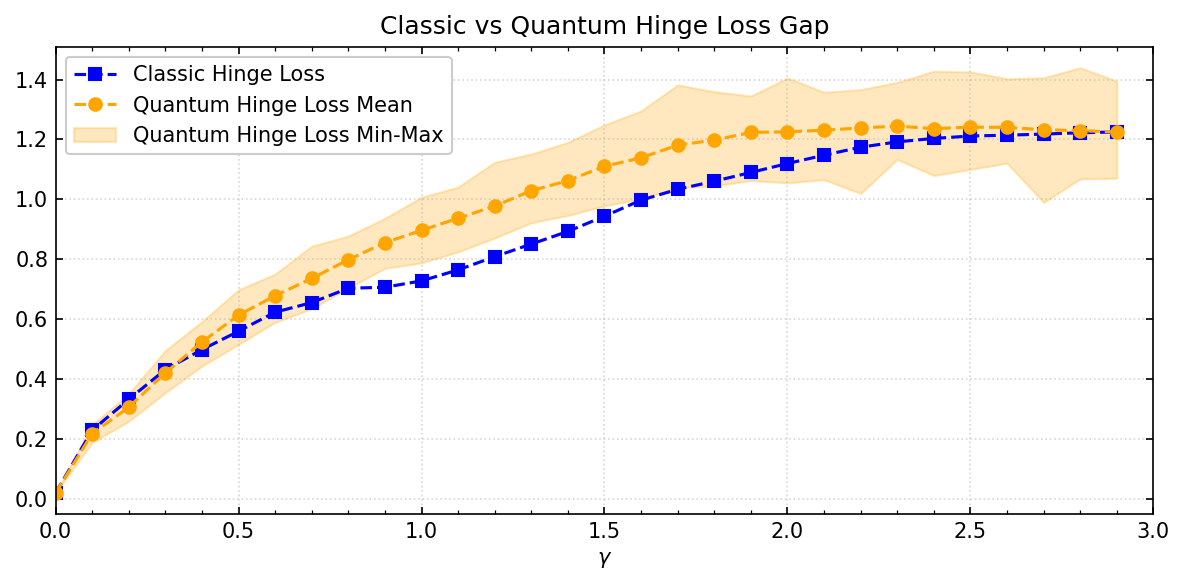

In [172]:
# (1) Hinge loss gap
fig, ax = plt.subplots(
    figsize=(8, 4),
    dpi=150,
    sharex=True
)

plot_classic_vs_quantum(
    ax = ax,
    gamma=gamma,
    classic=arr["C_hinge_gap"][0],
    quantum_stats=Q_hinge_gap,
    title="Classic vs Quantum Hinge Loss Gap",
    classic_label="Classic Hinge Loss",
    quantum_label="Quantum Hinge Loss Mean",
    band_label="Quantum Hinge Loss Min-Max",
    # ylim=(1e-6, 1)
)

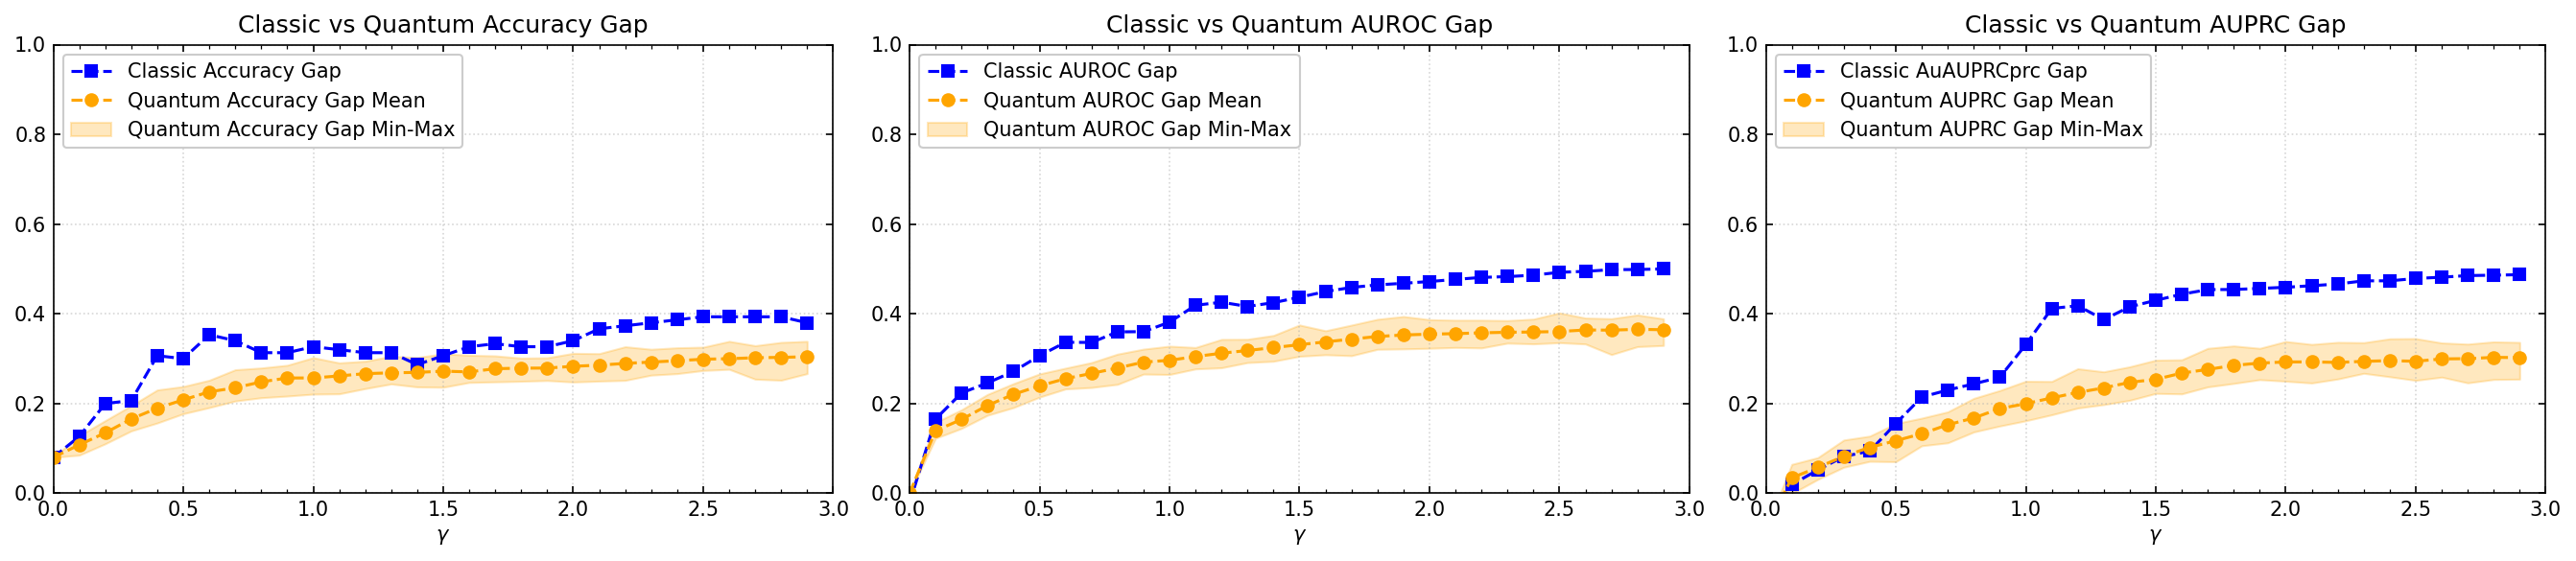

In [171]:
# (2) Accuracy gap
fig, axes = plt.subplots(
    1, 3,
    figsize = (18, 4),
    dpi = 150,
    sharex = True
)


plot_classic_vs_quantum(
    ax = axes[0],
    gamma=gamma,
    classic=arr["C_gap_acc"][0],
    quantum_stats=Q_gap_acc,
    title="Classic vs Quantum Accuracy Gap",
    classic_label="Classic Accuracy Gap",
    quantum_label="Quantum Accuracy Gap Mean",
    band_label="Quantum Accuracy Gap Min-Max",
    ylim =(0, 1) 
)

plot_classic_vs_quantum(
    ax = axes[1],
    gamma=gamma,
    classic=arr["C_gap_auroc"][0],
    quantum_stats=Q_gap_auroc,
    title="Classic vs Quantum AUROC Gap",
    classic_label="Classic AUROC Gap",
    quantum_label="Quantum AUROC Gap Mean",
    band_label="Quantum AUROC Gap Min-Max",
    ylim = (0, 1)
)

plot_classic_vs_quantum(
    ax = axes[2],
    gamma=gamma,
    classic=arr["C_gap_auprc"][0],
    quantum_stats=Q_gap_auprc,
    title="Classic vs Quantum AUPRC Gap",
    classic_label="Classic AuAUPRCprc Gap",
    quantum_label="Quantum AUPRC Gap Mean",
    band_label="Quantum AUPRC Gap Min-Max",
    ylim = (0, 1)
)

In [163]:
def Dic(max_list, mean_list, min_list):

    dic = {"max":max_list, "mean":mean_list, "min":min_list}

    return dic

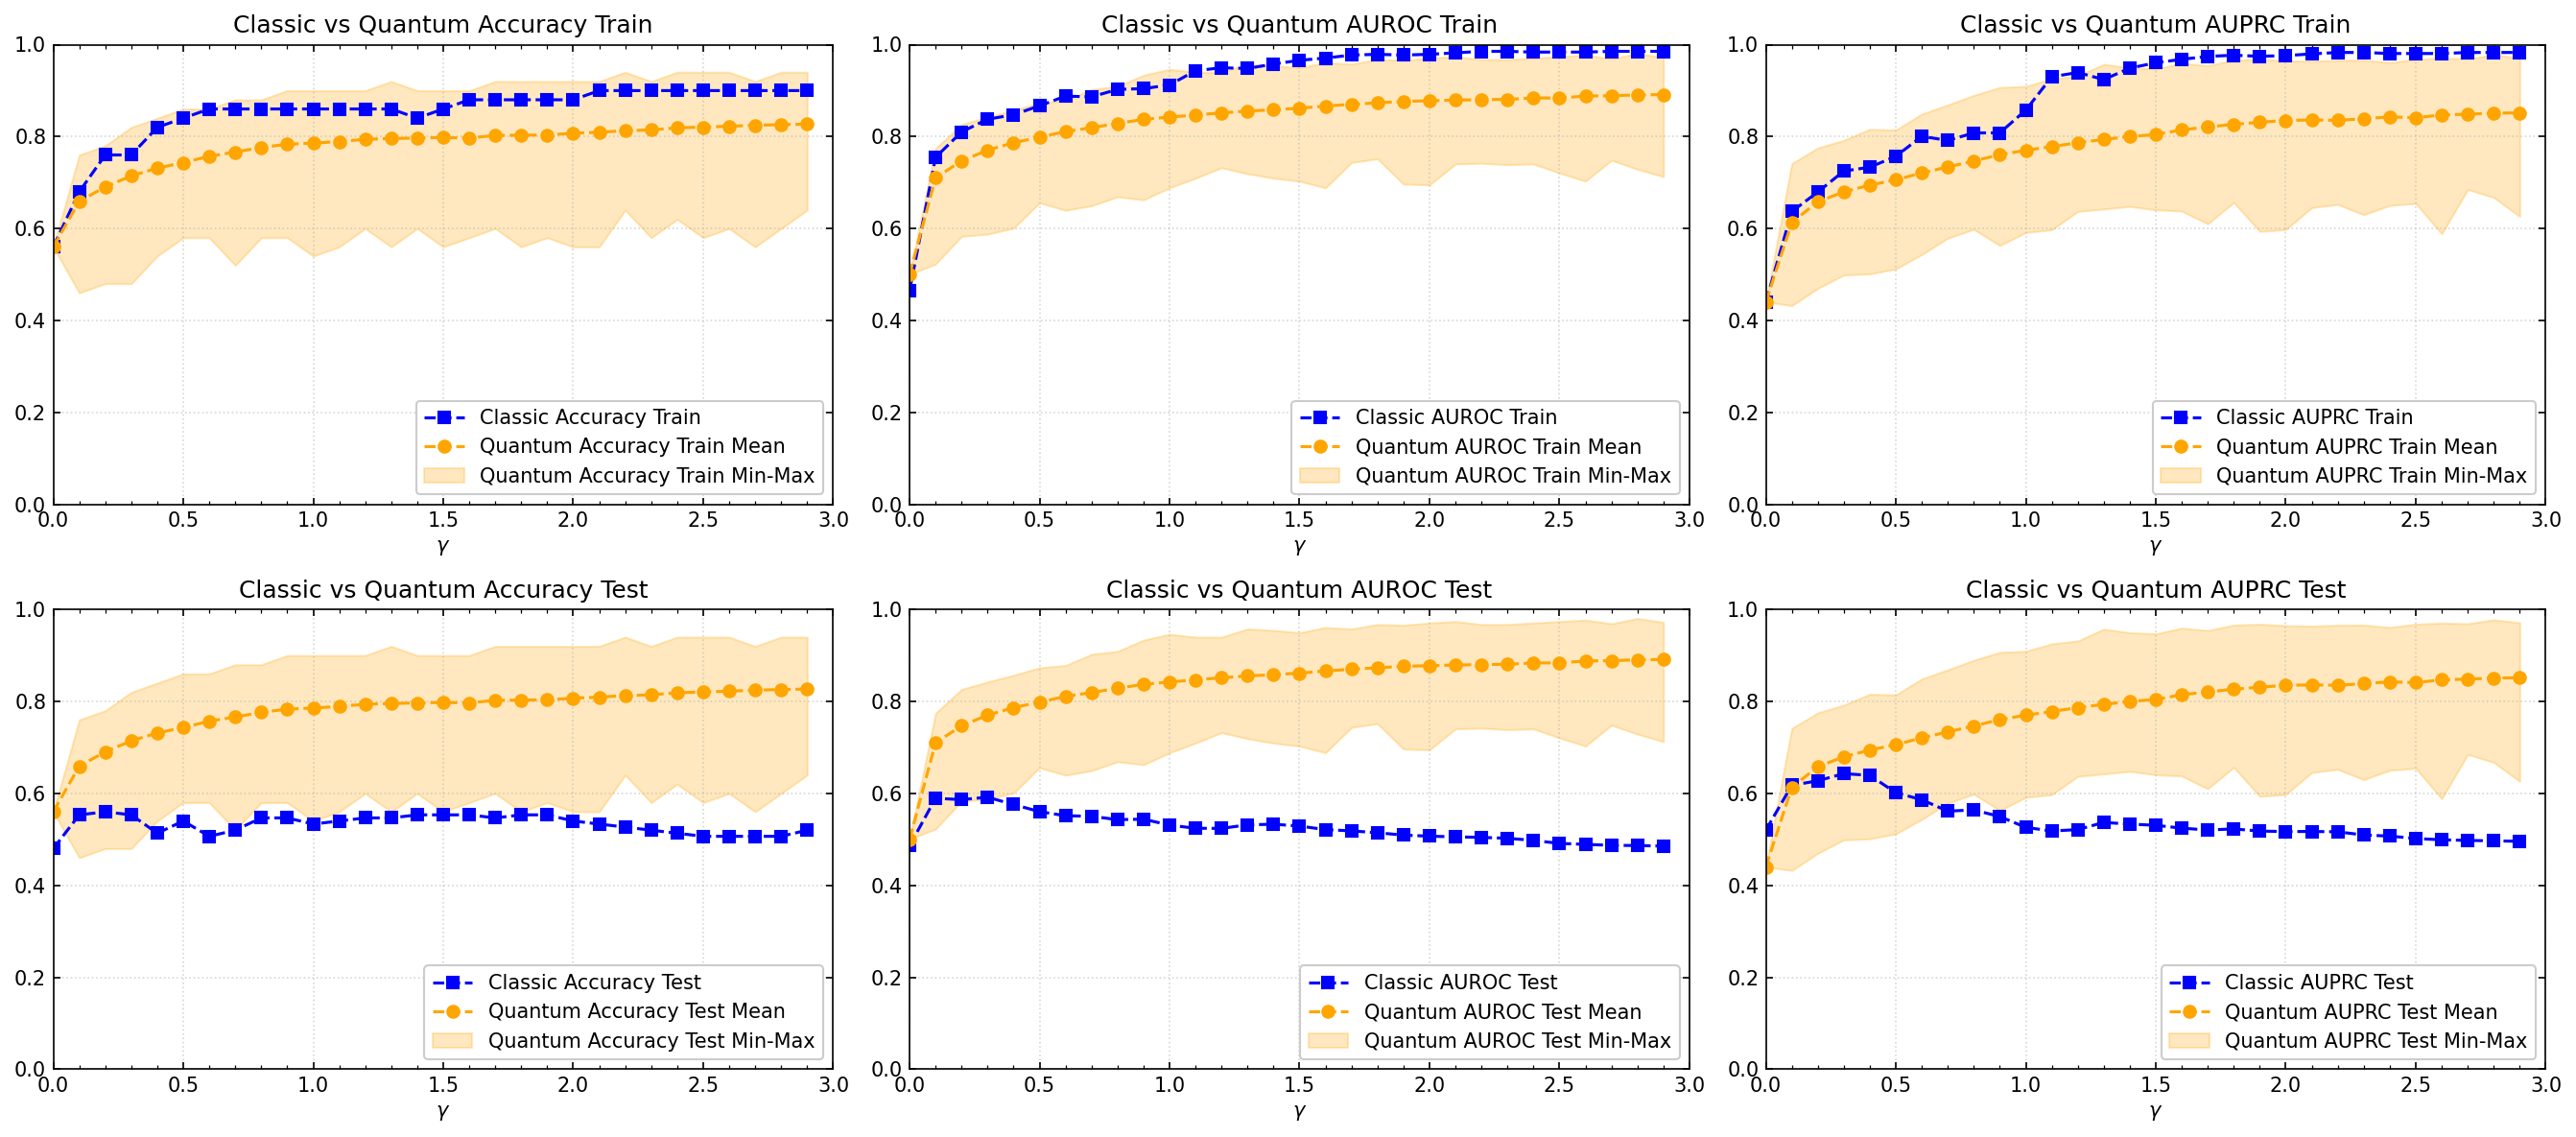

In [164]:
# (4) AUPRC gap
fig, axes = plt.subplots(
    2, 3,
    figsize = (18, 8),
    dpi = 150
)

plot_classic_vs_quantum(
    ax = axes[0, 0],
    gamma=gamma,
    classic=arr["C_acc_train"][0],
    quantum_stats = Dic(Q_acc_train_Max["max"], Q_acc_train_mean["mean"], Q_acc_train_Min["min"]),
    title="Classic vs Quantum Accuracy Train",
    classic_label="Classic Accuracy Train",
    quantum_label="Quantum Accuracy Train Mean",
    band_label="Quantum Accuracy Train Min-Max",
    ylim = (0, 1),
    loc = "lower right"
)

plot_classic_vs_quantum(
    ax = axes[0, 1],
    gamma=gamma,
    classic=arr["C_auroc_train"][0],
    quantum_stats=Dic(Q_auroc_train_Max["max"], Q_auroc_train_mean["mean"], Q_auroc_train_Min["min"]),
    title="Classic vs Quantum AUROC Train",
    classic_label="Classic AUROC Train",
    quantum_label="Quantum AUROC Train Mean",
    band_label="Quantum AUROC Train Min-Max",
    ylim = (0, 1),
    loc = "lower right"
)

plot_classic_vs_quantum(
    ax = axes[0, 2],
    gamma=gamma,
    classic=arr["C_auprc_train"][0],
    quantum_stats=Dic(Q_auprc_train_Max["max"], Q_auprc_train_mean["mean"], Q_auprc_train_Min["min"]),
    title="Classic vs Quantum AUPRC Train",
    classic_label="Classic AUPRC Train",
    quantum_label="Quantum AUPRC Train Mean",
    band_label="Quantum AUPRC Train Min-Max",
    ylim = (0, 1),
    loc = "lower right"
)

plot_classic_vs_quantum(
    ax = axes[1, 0],
    gamma=gamma,
    classic=arr["C_acc_test"][0],
    quantum_stats=Dic(Q_acc_test_Max["max"], Q_acc_test_mean["mean"], Q_acc_test_Min["min"]),
    title="Classic vs Quantum Accuracy Test",
    classic_label="Classic Accuracy Test",
    quantum_label="Quantum Accuracy Test Mean",
    band_label="Quantum Accuracy Test Min-Max",
    ylim = (0, 1),
    loc = "lower right"
)

plot_classic_vs_quantum(
    ax = axes[1, 1],
    gamma=gamma,
    classic=arr["C_auroc_test"][0],
    quantum_stats=Dic(Q_auroc_test_Max["max"], Q_auroc_test_mean["mean"], Q_auroc_test_Min["min"]),
    title="Classic vs Quantum AUROC Test",
    classic_label="Classic AUROC Test",
    quantum_label="Quantum AUROC Test Mean",
    band_label="Quantum AUROC Test Min-Max",
    ylim = (0, 1),
    loc = "lower right"
)

plot_classic_vs_quantum(
    ax = axes[1, 2],
    gamma=gamma,
    classic=arr["C_auprc_test"][0],
    quantum_stats=Dic(Q_auprc_test_Max["max"], Q_auprc_test_mean["mean"], Q_auprc_test_Min["min"]),
    title="Classic vs Quantum AUPRC Test",
    classic_label="Classic AUPRC Test",
    quantum_label="Quantum AUPRC Test Mean",
    band_label="Quantum AUPRC Test Min-Max",
    ylim = (0, 1),
    loc = "lower right"
)

In [165]:
Q_J = {
    "min": Q_J_xi["min"] + Q_J_w["min"],
    "mean": Q_J_xi["mean"] + Q_J_w["mean"],
    "max": Q_J_xi["max"] + Q_J_w["max"],
}

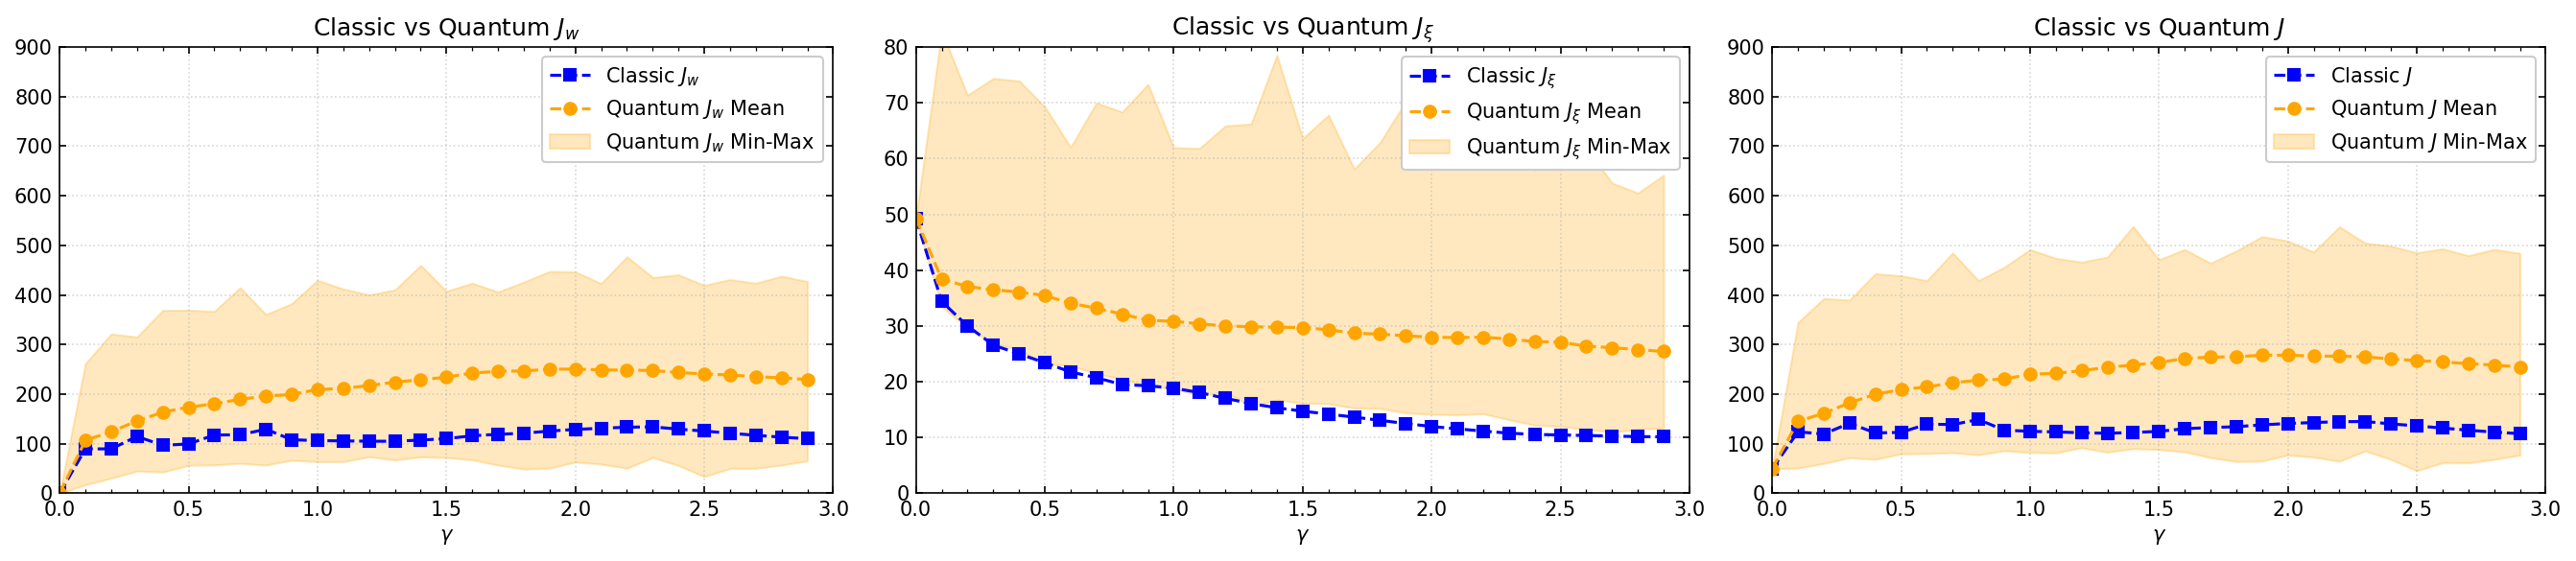

In [166]:
fig, axes = plt.subplots(
    1,3,
    figsize = (18, 4),
    dpi = 150
)

plot_classic_vs_quantum(
    ax = axes[0],
    gamma=gamma,
    classic=arr["C_J_w"][0],
    quantum_stats=Q_J_w,
    title=r"Classic vs Quantum $J_w$",
    classic_label=r"Classic $J_w$",
    quantum_label=r"Quantum $J_w$ Mean",
    band_label=r"Quantum $J_w$ Min-Max",
    ylim = (0, 900),
    loc = "upper right"
)

plot_classic_vs_quantum(
    ax = axes[1],
    gamma=gamma,
    classic=arr["C_J_xi"][0],
    quantum_stats=Q_J_xi,
    title=r"Classic vs Quantum $J_{\xi}$",
    classic_label=r"Classic $J_{\xi}$",
    quantum_label=r"Quantum $J_{\xi}$ Mean",
    band_label=r"Quantum $J_{\xi}$ Min-Max",
    ylim = (0, 80),
    loc = "upper right"
)

plot_classic_vs_quantum(
    ax = axes[2],
    gamma=gamma,
    classic=(arr["C_J_xi"][0] + arr["C_J_w"][0]),
    quantum_stats=Q_J,
    title=r"Classic vs Quantum $J$",
    classic_label=r"Classic $J$",
    quantum_label=r"Quantum $J$ Mean",
    band_label=r"Quantum $J$ Min-Max",
    ylim = (0, 900),
    loc = "upper right"
)

In [175]:
seed_dir = r"/home/csb/SVM/Support-Vector-Machine-2/SVM_Data/alpha data/seed_43/seed_43"

files = [f for f in os.listdir(seed_dir) if f.endswith(".npz")]
print("len(files) =", len(files))
print("expected   =", N_RUNS * N_GAMMA)

key = lambda f: (int(re.search(r"run(\d+)", f).group(1)),
                 float(re.search(r"_g([0-9.]+)", f).group(1)))

files_matrix = np.array(sorted(files, key=key)).reshape(N_RUNS, N_GAMMA)

Q_matrix = []
C_matrix = []

# C_matrix = np.zeros((N_RUNS, N_GAMMA, N_ALPHA))
# Q_matrix = np.zeros((N_RUNS, N_GAMMA, TOP_K, N_ALPHA))

for i in range(N_RUNS):
    
    Q_alpha_list = []
    C_alpha_list = []

    for j in range(N_GAMMA):

        Q_alpha = []
        C_alpha = []

        data = np.load(os.path.join(seed_dir, files_matrix[i, j]))

        C_alpha = data["C_alpha"]
        Q_alpha = data["Q_alpha"]

        C_alpha_list.append(C_alpha)
        Q_alpha_list.append(Q_alpha)

    C_matrix.append(C_alpha_list)
    Q_matrix.append(Q_alpha_list)

C_matrix = np.array(C_matrix)
Q_matrix = np.array(Q_matrix)

#C_matrix: [RUN, GAMMA, ALPHA]
#Q_matrix: [RUN, GAMMA, top_k, alpha]

len(files) = 3000
expected   = 3000


In [176]:
def plot_alpha_mean_count(C_matrix, Q_matrix, g_idx,
                          bin_mode="integer", bins=60):

    C_gamma = np.asarray(C_matrix[:, g_idx, :])
    Q_gamma = np.asarray(Q_matrix[:, g_idx, :, :])

    N_RUNS, TOP_K, N_ALPHA = Q_gamma.shape

    vmin = min(C_gamma.min(), Q_gamma.min())
    vmax = max(C_gamma.max(), Q_gamma.max())

    # -------------------------
    # Bin 설정
    # -------------------------
    if bin_mode == "integer":
        bin_edges = np.arange(np.floor(vmin) - 0.5,
                              np.ceil(vmax) + 1.5,
                              1)
    elif bin_mode == "auto":
        bin_edges = np.histogram_bin_edges(
            np.concatenate([C_gamma.flatten(),
                            Q_gamma.flatten()]),
            bins="auto"
        )
    elif bin_mode == "custom":
        bin_edges = np.linspace(vmin, vmax, bins+1)
    else:
        raise ValueError("bin_mode must be integer / auto / custom")

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_width = bin_edges[1] - bin_edges[0]

    # -------------------------
    # Classical 평균
    # -------------------------
    C_hists = []
    for run in range(C_gamma.shape[0]):
        h, _ = np.histogram(C_gamma[run], bins=bin_edges)
        C_hists.append(h)
    C_hist_mean = np.mean(np.stack(C_hists), axis=0)

    # -------------------------
    # Quantum 평균 (400개)
    # -------------------------
    Q_hists = []
    for r in range(N_RUNS):
        for k in range(TOP_K):
            h, _ = np.histogram(Q_gamma[r, k], bins=bin_edges)
            Q_hists.append(h)
    Q_hist_mean = np.mean(np.stack(Q_hists), axis=0)

    # -------------------------
    # Plot
    # -------------------------
    plt.figure(figsize=(8,5))

    plt.bar(bin_centers - 0.25 * bin_width,
            C_hist_mean,
            width=0.4*bin_width,
            alpha=0.6,
            label="Classical")

    plt.bar(bin_centers + 0.25*bin_width,
            Q_hist_mean,
            width=0.4*bin_width,
            alpha=0.6,
            label="Quantum")

    plt.xlabel("Alpha value")
    plt.ylabel("Alpha Count")
    plt.ylim(0, 50)
    plt.title(f"Alpha Count Distribution | gamma = {g_idx/10}")
    plt.legend()

    # ----- 여기 추가 -----
    ax = plt.gca()
    ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
    ax.xaxis.set_minor_locator(mticker.MultipleLocator(1))
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
    ax.grid(which='major', linestyle=':', linewidth=0.8, alpha=0.5)
    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)
    # ---------------------

    plt.tight_layout()
    plt.show()

    return C_hist_mean, Q_hist_mean, bin_edges

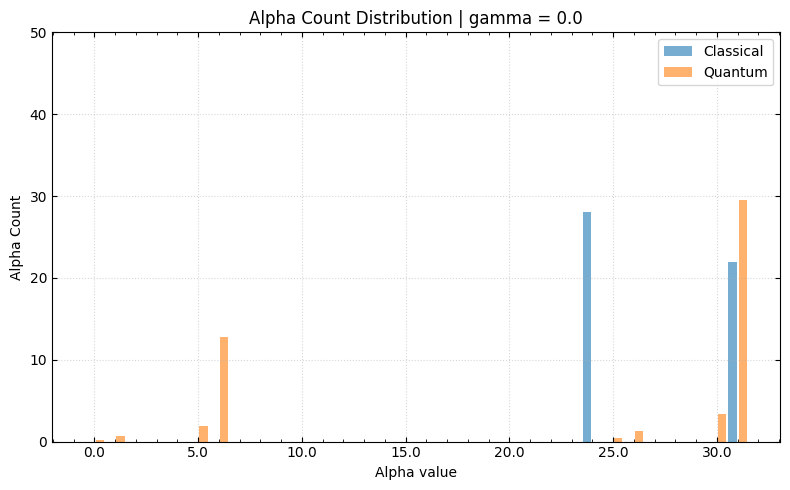

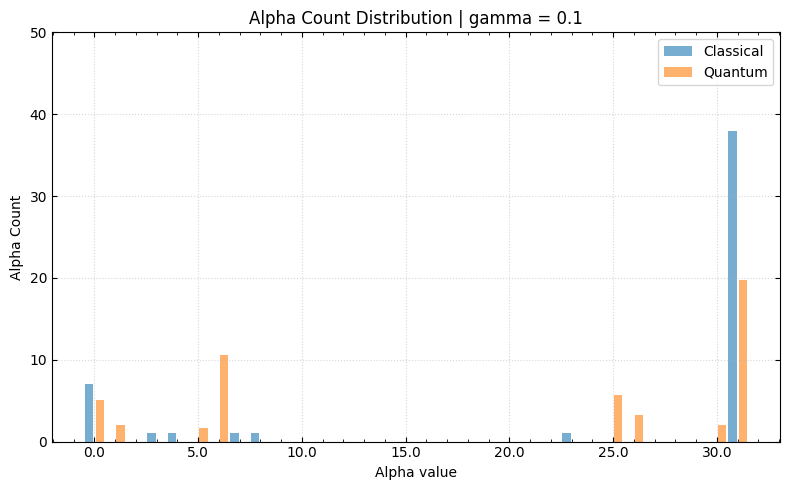

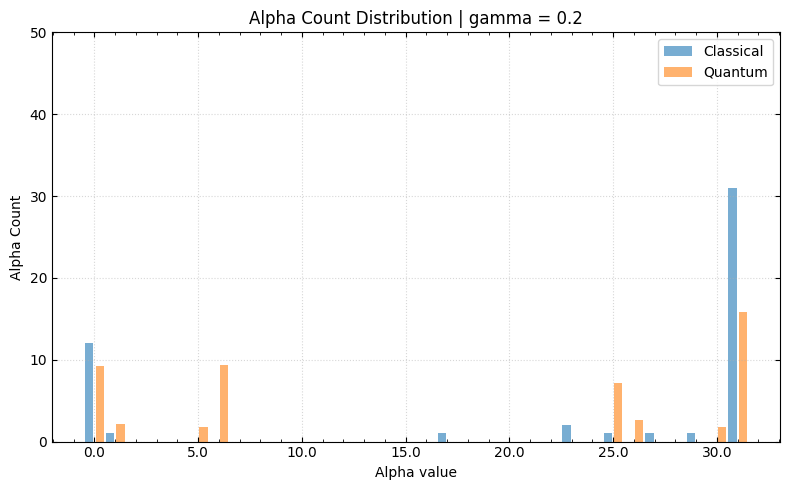

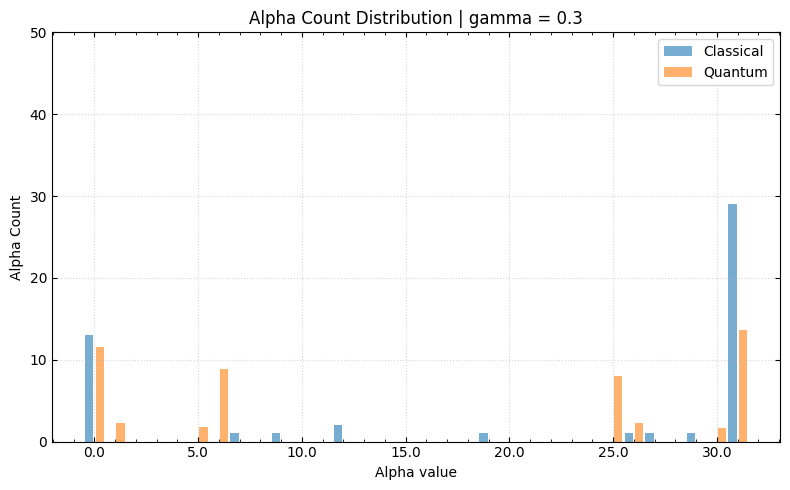

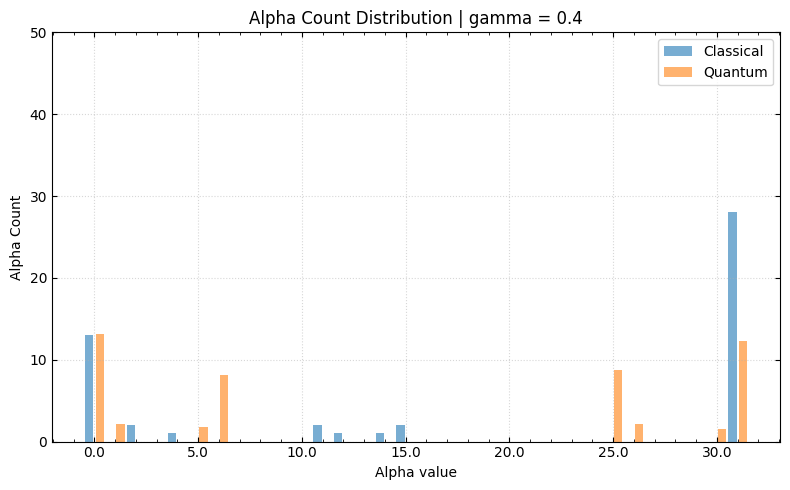

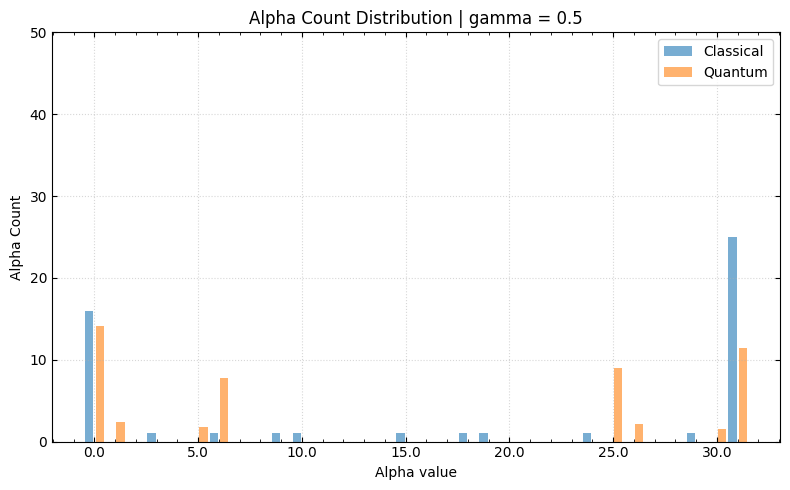

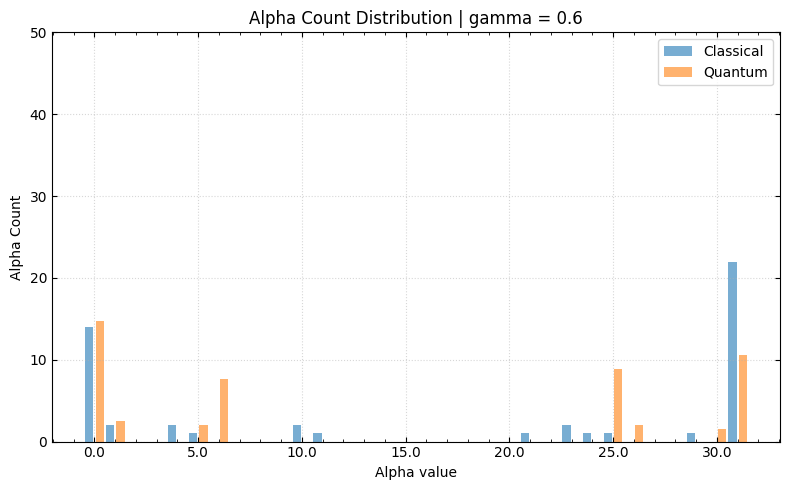

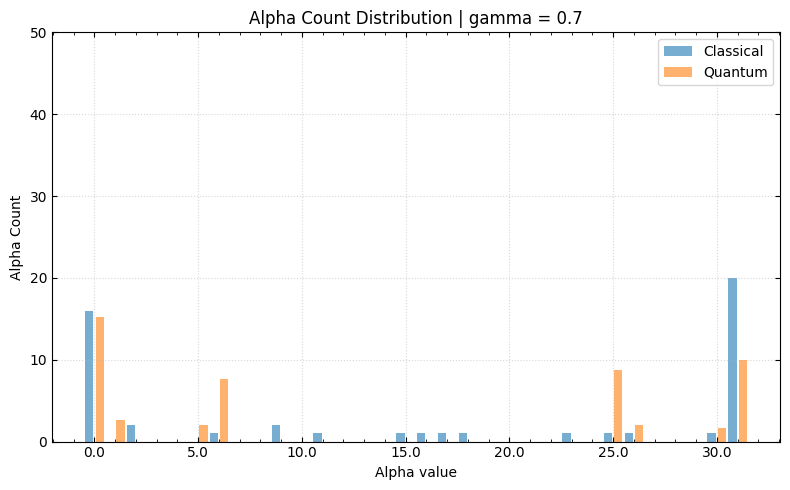

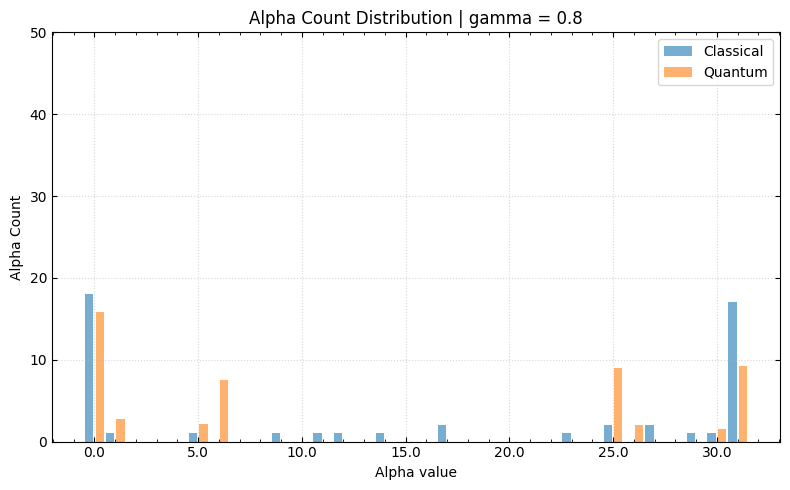

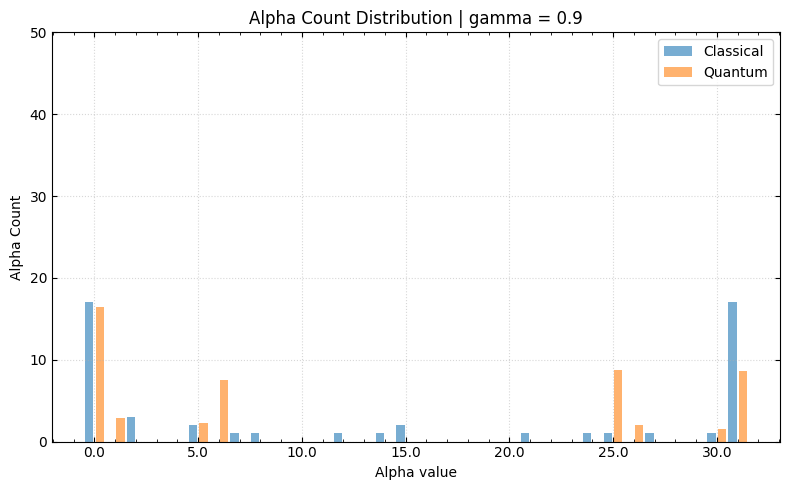

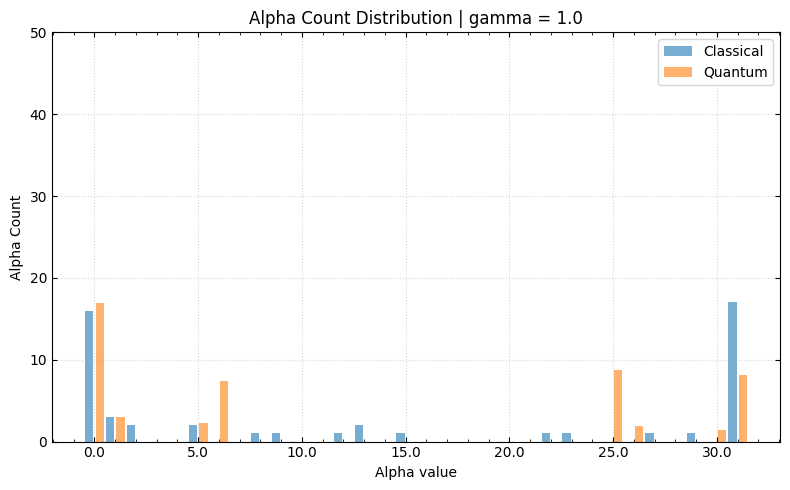

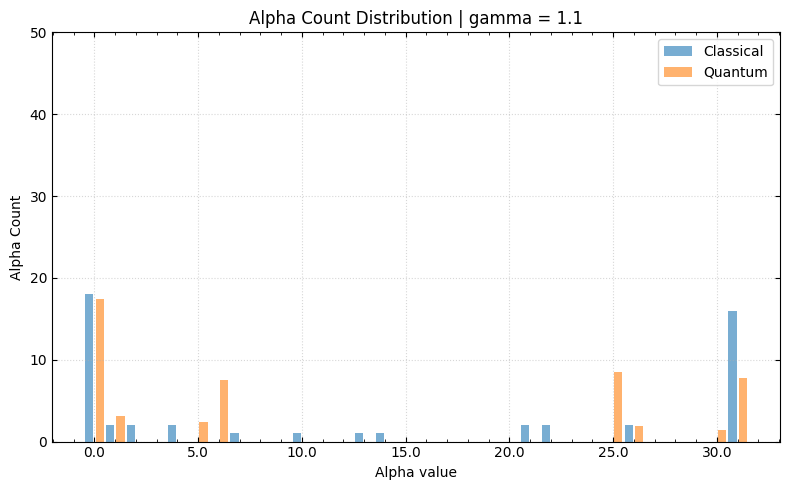

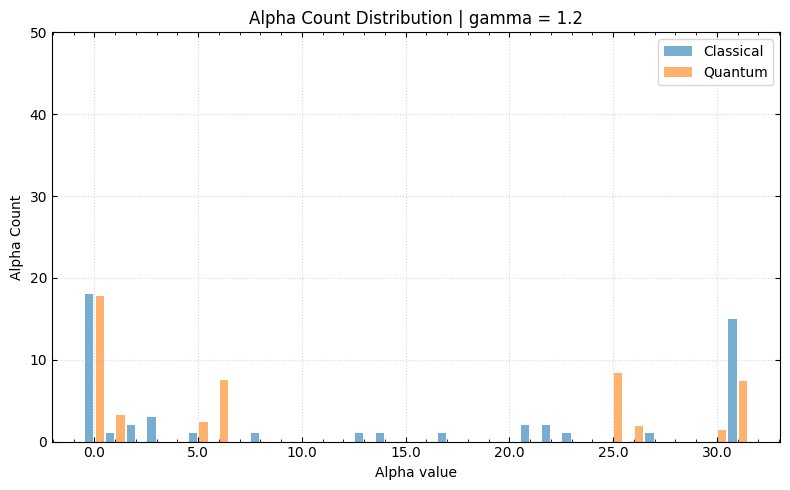

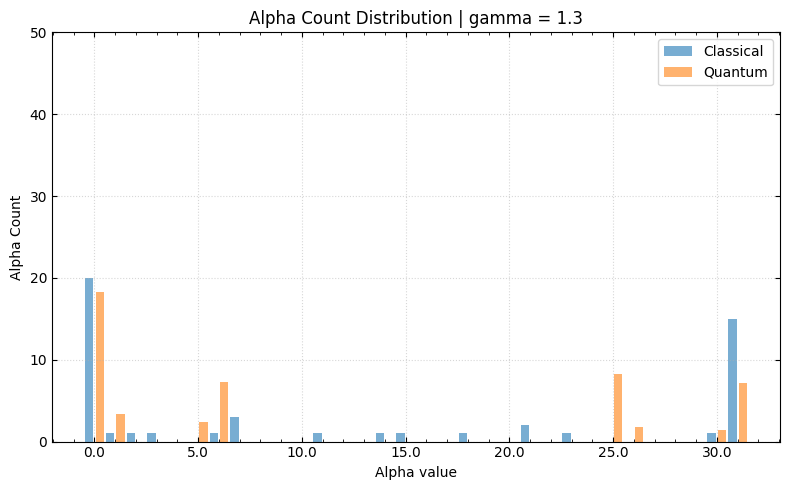

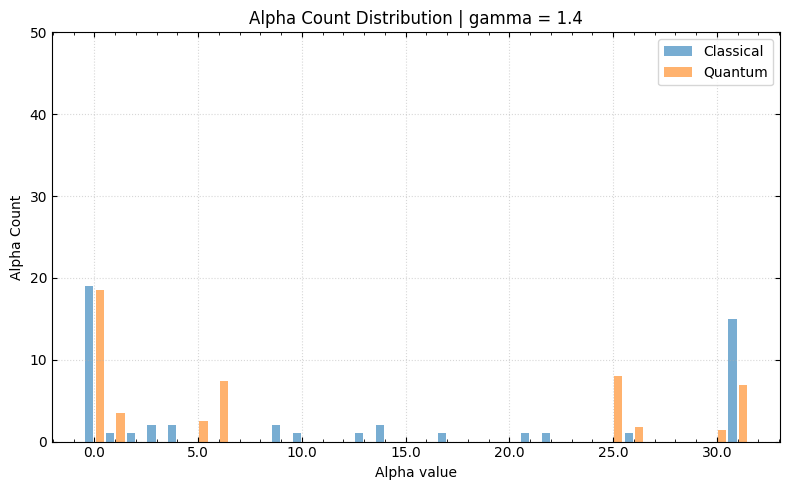

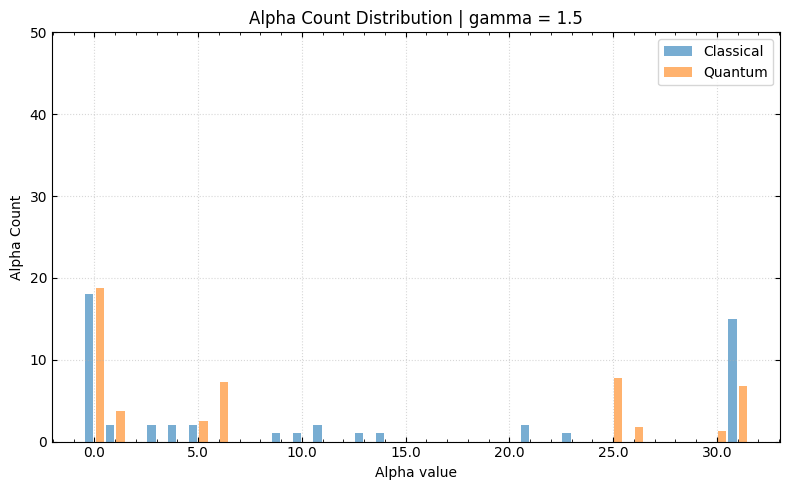

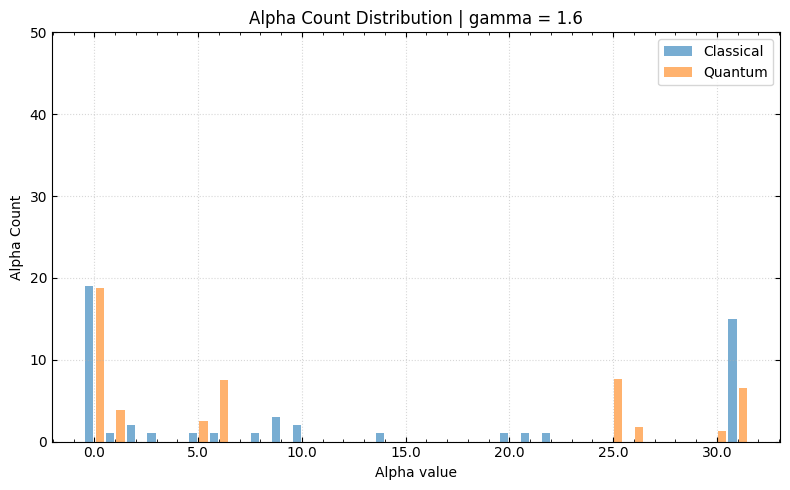

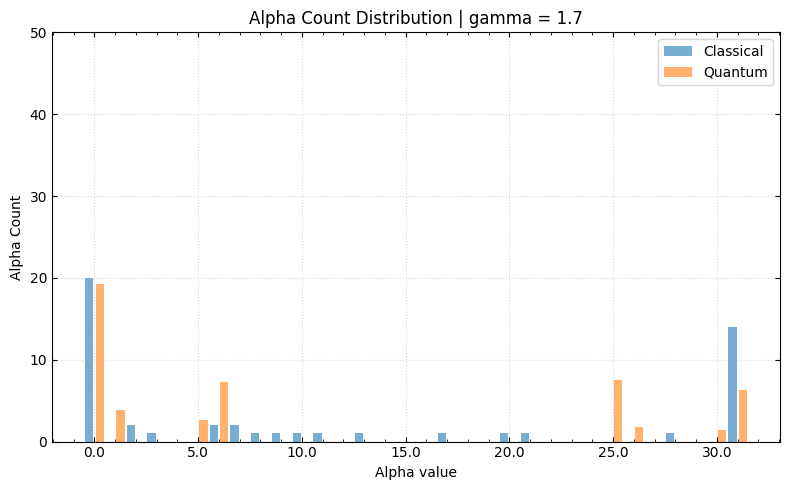

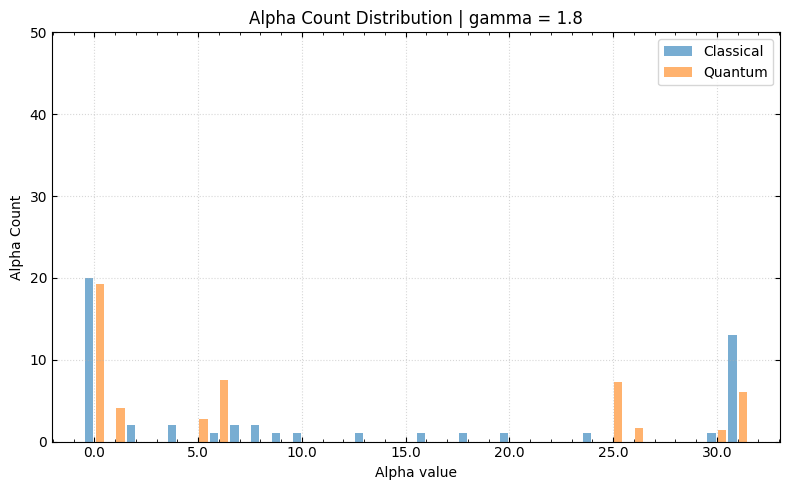

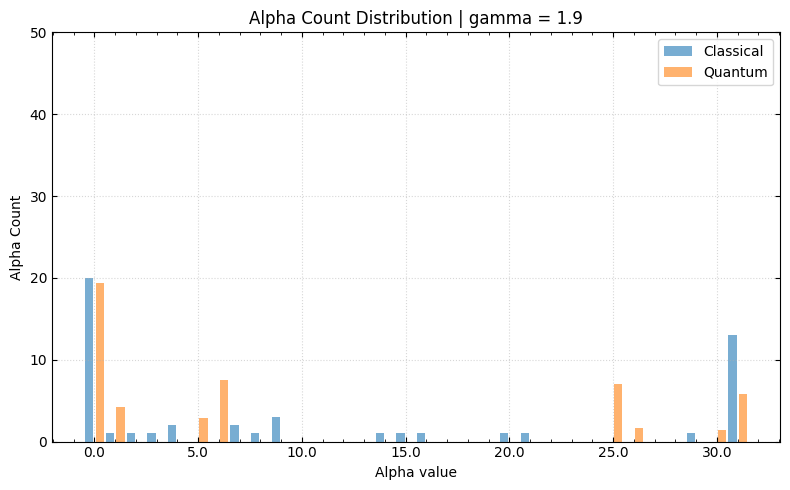

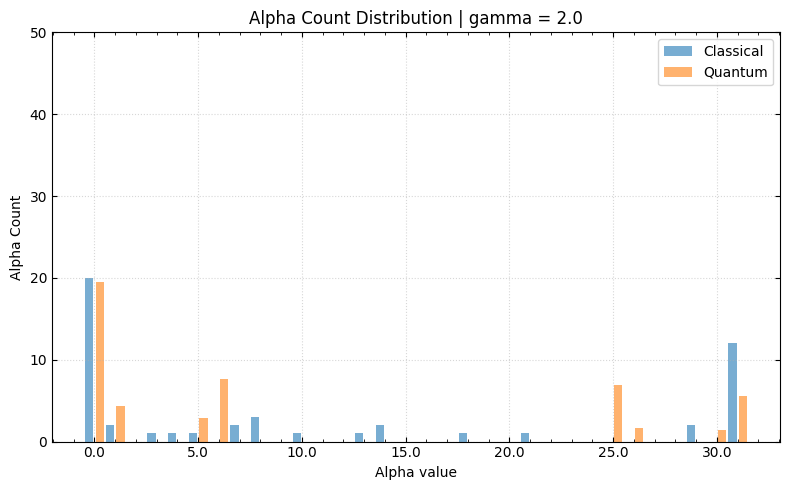

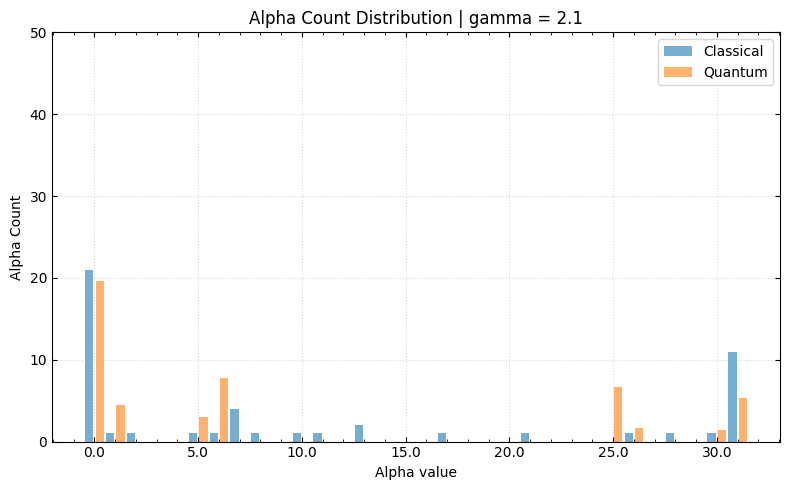

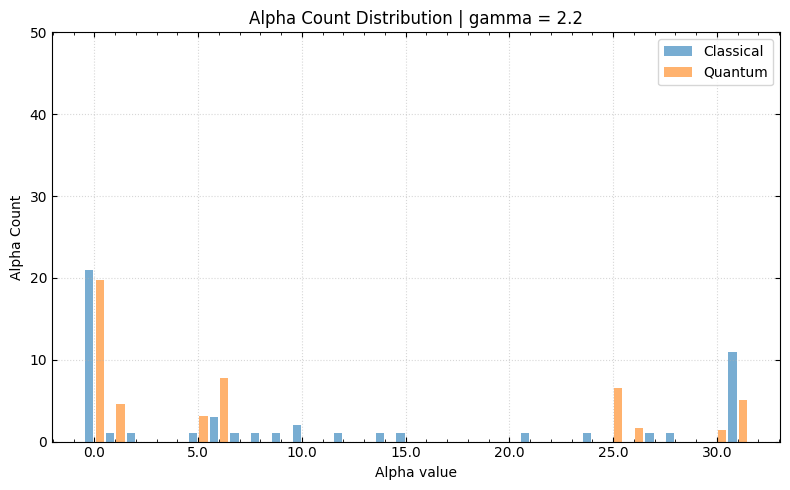

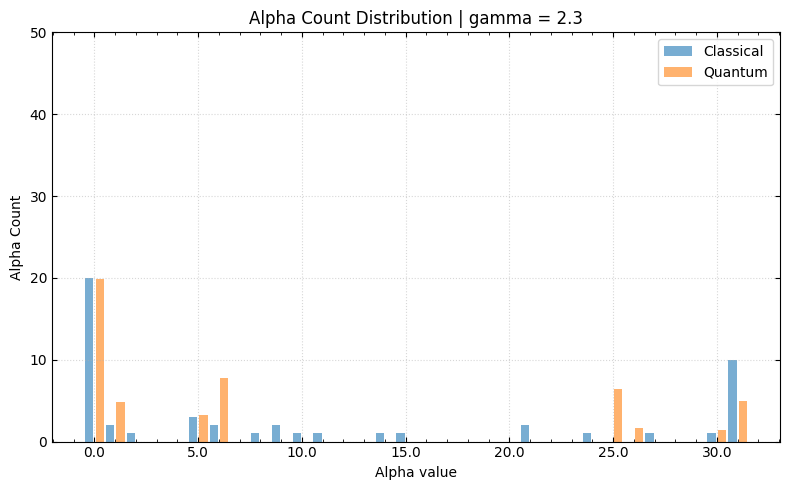

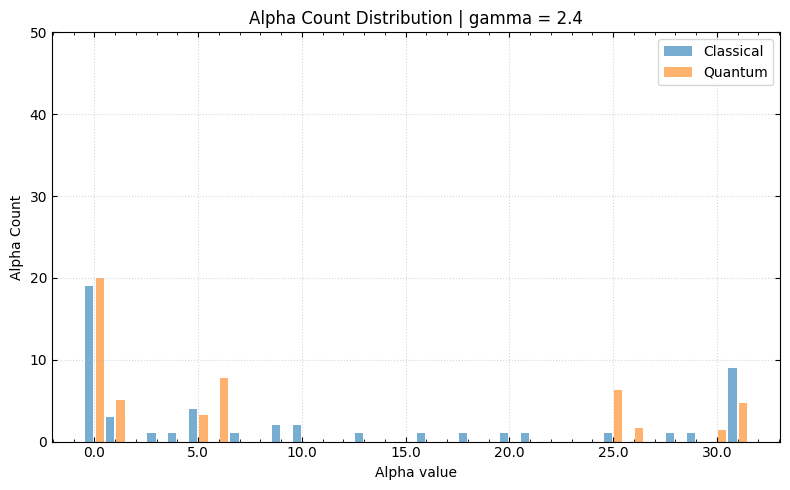

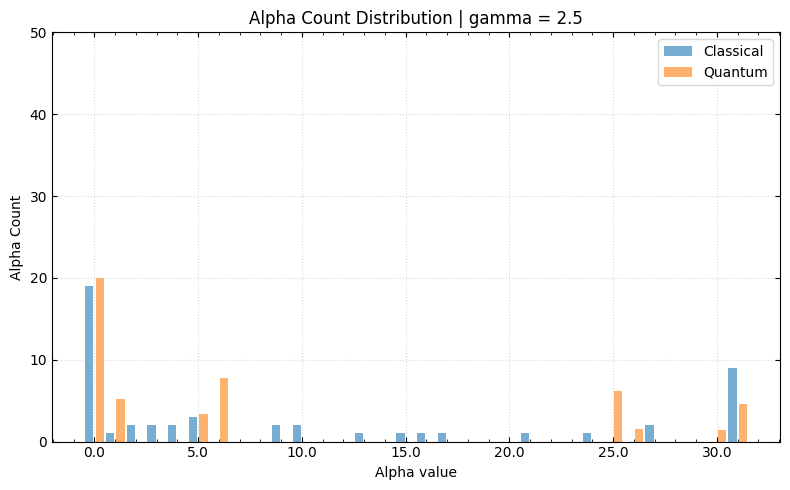

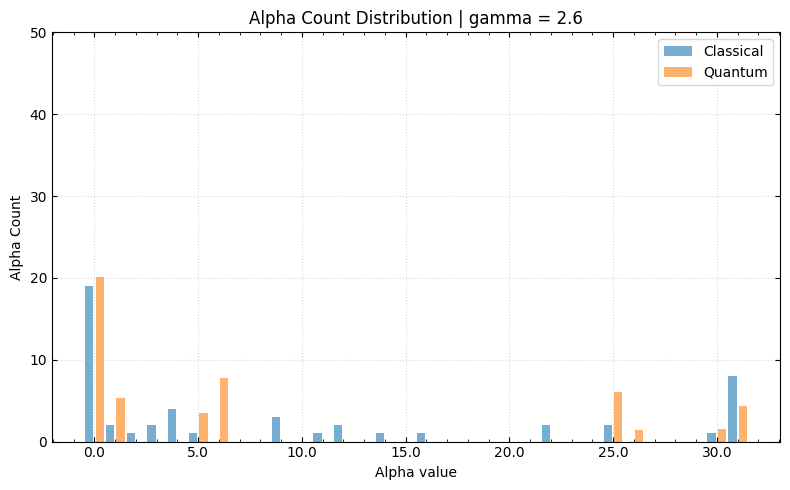

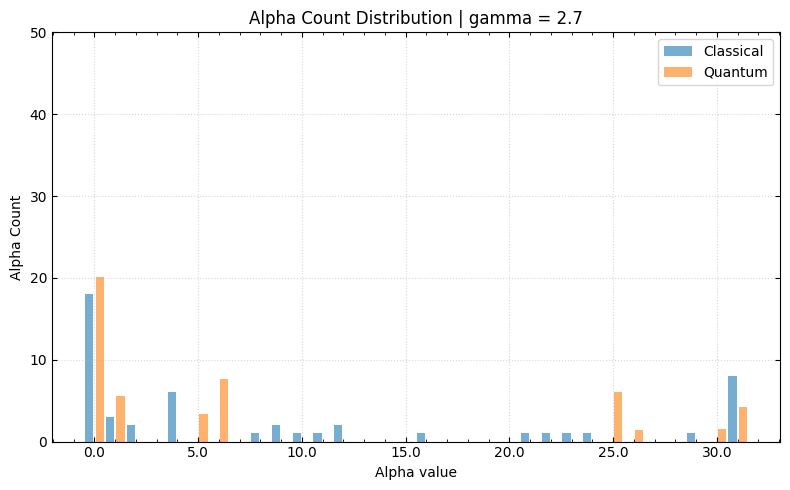

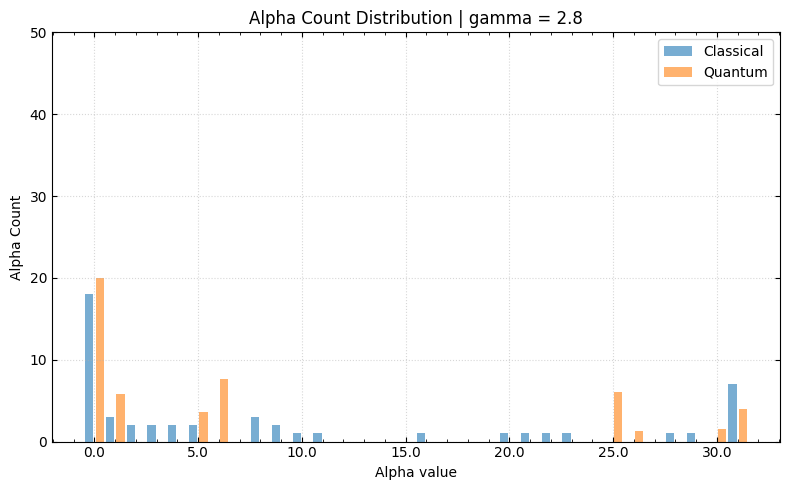

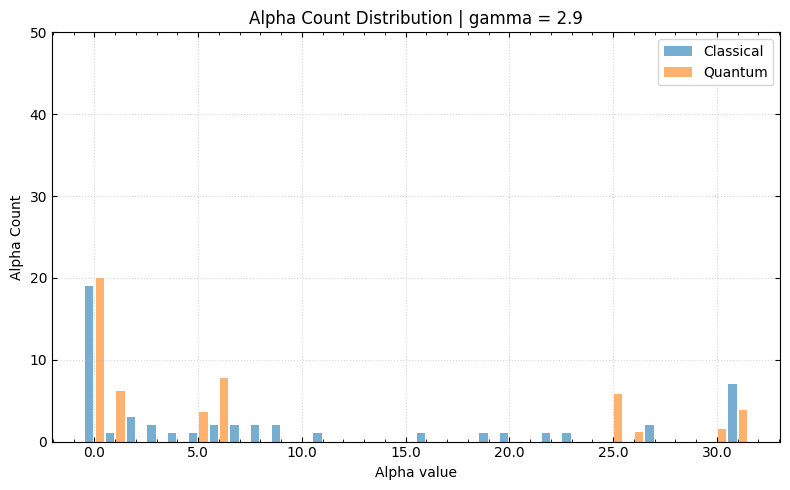

In [177]:
for i in range(len(gamma)):
    C_hist_mean, Q_hist_mean, bin_edges = plot_alpha_mean_count(C_matrix, Q_matrix, g_idx = i)

In [178]:
def plot_alpha_sum_from_mean_hist_vs_gamma(C_matrix, Q_matrix,
                                           gamma_list=None,
                                           bin_mode="integer", bins=60,
                                           use_std_band=False):
    """
    평균 히스토그램(mean count)으로부터
    gamma별 sum(alpha) = Σ_bin (bin_center * mean_count_bin)
    를 계산해 plot.

    - 반복 횟수(RUNS, RUNS*TOP_K)를 '곱하지 않음' (mean count 기반).
    - std_band는 "sum(alpha)"의 샘플 분포(런별/런×topk별)를 이용해 그립니다.
      (원하면 꺼도 됨)
    """
    C = np.asarray(C_matrix)              # (N_RUNS, N_GAMMA, N_ALPHA)
    Q = np.asarray(Q_matrix)              # (N_RUNS, N_GAMMA, TOP_K, N_ALPHA)

    N_RUNS, N_GAMMA, N_ALPHA = C.shape
    _, _, TOP_K, _ = Q.shape

    # ---- x축
    if gamma_list is None:
        x = np.arange(N_GAMMA)
        x_label = "Gamma index"
    else:
        gamma_list = np.asarray(gamma_list)
        assert gamma_list.shape[0] == N_GAMMA
        x = gamma_list
        x_label = r"$\gamma$"

    C_mean = np.zeros(N_GAMMA); C_std = np.zeros(N_GAMMA)
    Q_mean = np.zeros(N_GAMMA); Q_std = np.zeros(N_GAMMA)

    for g in range(N_GAMMA):
        C_gamma = C[:, g, :]            # (N_RUNS, N_ALPHA)
        Q_gamma = Q[:, g, :, :]         # (N_RUNS, TOP_K, N_ALPHA)

        vmin = min(C_gamma.min(), Q_gamma.min())
        vmax = max(C_gamma.max(), Q_gamma.max())

        # ---- bin 설정 (plot_alpha_mean_count와 동일 로직)
        if bin_mode == "integer":
            bin_edges = np.arange(np.floor(vmin) - 0.5,
                                  np.ceil(vmax) + 1.5, 1)
        elif bin_mode == "auto":
            bin_edges = np.histogram_bin_edges(
                np.concatenate([C_gamma.ravel(), Q_gamma.ravel()]),
                bins="auto"
            )
        elif bin_mode == "custom":
            bin_edges = np.linspace(vmin, vmax, bins + 1)
        else:
            raise ValueError("bin_mode must be integer / auto / custom")

        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

        # =========================
        # 1) mean histogram (count 평균)
        # =========================
        # Classical mean hist
        C_hists = []
        for r in range(N_RUNS):
            h, _ = np.histogram(C_gamma[r], bins=bin_edges)
            C_hists.append(h)
        C_hist_mean = np.mean(np.stack(C_hists), axis=0)     # (n_bins,)

        # Quantum mean hist (run×topk 평균)
        Q_hists = []
        for r in range(N_RUNS):
            for k in range(TOP_K):
                h, _ = np.histogram(Q_gamma[r, k], bins=bin_edges)
                Q_hists.append(h)
        Q_hist_mean = np.mean(np.stack(Q_hists), axis=0)     # (n_bins,)

        # =========================
        # 2) "평균값의 합"으로 sum(alpha) 복원
        #    sum(alpha) ≈ Σ bin_center * mean_count
        # =========================
        C_mean[g] = np.sum(bin_centers * C_hist_mean)
        Q_mean[g] = np.sum(bin_centers * Q_hist_mean)

        # =========================
        # 3) (선택) 표준편차 band:
        #    샘플별 sum(alpha)를 직접 계산한 뒤 std
        #    -> mean에 반복 횟수 곱해지지 않음
        # =========================
        if use_std_band:
            C_sums = np.sum(C_gamma, axis=1)                         # (N_RUNS,)
            Q_sums = np.sum(Q_gamma, axis=-1).reshape(-1)            # (N_RUNS*TOP_K,)
            C_std[g] = np.std(C_sums, ddof=1) if C_sums.size > 1 else 0.0
            Q_std[g] = np.std(Q_sums, ddof=1) if Q_sums.size > 1 else 0.0
        else:
            C_std[g] = 0.0
            Q_std[g] = 0.0

    # ---- plot
    plt.figure(figsize=(7, 4), dpi=1500)
    plt.plot(x, C_mean, "s--", linewidth=2, label="Classical sum(alpha)")
    plt.plot(x, Q_mean, "o--", linewidth=2, label="Quantum sum(alpha)")

    if use_std_band:
        plt.fill_between(x, C_mean - C_std, C_mean + C_std, alpha=0.15)
        plt.fill_between(x, Q_mean - Q_std, Q_mean + Q_std, alpha=0.15)

    plt.xlabel(x_label)
    plt.ylabel("sum (alpha)")
    plt.title("Classical vs Quantum sum(alpha)")
    plt.grid(alpha=0.25)
    plt.legend(frameon=True)
    plt.tight_layout()
    plt.show()
 
    return C_mean, C_std, Q_mean, Q_std

In [179]:
C_mean, C_std, Q_mean, Q_std = plot_alpha_sum_from_mean_hist_vs_gamma(C_matrix, Q_matrix, gamma_list=gamma)

In [180]:
print(C_matrix.shape)
print(Q_matrix.shape)

(100, 30, 50)
(100, 30, 20, 50)


In [181]:
n_train = 50
X, Y = make_circles(n_samples=200, noise=0.1, random_state=44)

X_train = X[:n_train, :]
X_test  = X[n_train:, :]
y_train = 2 * Y[:n_train] - 1
y_test  = 2 * Y[n_train:] - 1

N_train = X_train.shape[0]

In [182]:
def Kernel(i):
    _, _, _, _, _, _, K_train_train = CG.Solver_Parameter(N_train, X_train, y_train, gamma[i], C)
    K_train_train_q, Q = QG.Q_metric(N_train, X_train, y_train, B, K, xi, gamma[i])

    return K_train_train, K_train_train_q

In [183]:
def Low_Energy():
    Energy_Data = {}
    for i in range(N_GAMMA):
        alpha_Q = []

       
        C_J_w, C_J_xi = CG.Primal(C_matrix[0][i], Kernel(i)[0], y_train, C)
        C_J = C_J_w + C_J_xi

        for run_idx in range(N_RUNS):

            for j in range(TOP_K):
                Q_J_w, Q_J_xi = QG.Primal(Q_matrix[run_idx][i][j], Kernel(i)[1], y_train, C)
                Q_J = Q_J_w + Q_J_xi

                if Q_J < C_J:
                    alpha_Q.append(Q_matrix[run_idx][i][j])

        alpha_C = (C_matrix[0][i])

        Energy_Data[gamma[i]] = {
            "classic": alpha_C, 
            "quantum": alpha_Q
        }

    return Energy_Data

In [184]:
Energy_Data = Low_Energy()

In [189]:
C_acc_train_list = []
Q_acc_train_array = []

C_auroc_train_list = []
Q_auroc_train_array = []

C_auprc_train_list = []
Q_auprc_train_array = []

C_Loss_train_list = []
Q_Loss_train_array = []

for i in range(N_GAMMA):

    # -------------------------
    # Classic
    # -------------------------
    C_acc_train, C_auroc_train, C_auprc_train, C_scores_train = CG.evaluate_train(
        y_train, Energy_Data[i/10]["classic"], Kernel(i)[0], C
    )

    C_loss_train, C_loss_test = CG.Hinge_Loss(
            X_train, X_test, y_train, y_test, Energy_Data[i/10]["classic"], Kernel(i)[0], C_scores_train, gamma[i], C
        )

    C_acc_train_list.append(C_acc_train)
    C_auroc_train_list.append(C_auroc_train)
    C_auprc_train_list.append(C_auprc_train)
    C_Loss_train_list.append(C_loss_train)

    # -------------------------
    # Quantum (중요: 매 gamma마다 초기화)
    # -------------------------
    Q_acc_train_list = []
    Q_auroc_train_list = []
    Q_auprc_train_list = []
    Q_Loss_train_list = []

    for j in range(len(Energy_Data[i/10]["quantum"])):

        Q_acc_train, Q_auroc_train, Q_auprc_train, Q_scores_train = QG.evaluate_train(
            y_train,
            Energy_Data[i/10]["quantum"][j],
            Kernel(i)[1],
            C
        )

        Q_loss_train, Q_loss_test = QG.Hinge_Loss(
                X_train, X_test, y_train, y_test, Energy_Data[i/10]["quantum"][j], Kernel(i)[1], Q_scores_train, gamma[i], C
            )

        Q_acc_train_list.append(Q_acc_train)
        Q_auroc_train_list.append(Q_auroc_train)
        Q_auprc_train_list.append(Q_auprc_train)
        Q_Loss_train_list.append(Q_loss_train)

    # gamma 단위 저장
    Q_acc_train_array.append(Q_acc_train_list)
    Q_auroc_train_array.append(Q_auroc_train_list)
    Q_auprc_train_array.append(Q_auprc_train_list)
    Q_Loss_train_array.append(Q_Loss_train_list)

# -------------------------
# 마지막에만 numpy 변환
# -------------------------
# Q_acc_train_array = np.array(Q_acc_train_array)
# Q_auroc_train_array = np.array(Q_auroc_train_array)
# Q_auprc_train_array = np.array(Q_auprc_train_array)

In [197]:
fig = go.Figure()

for i in range(30):
    gamma_val = gamma[i]

    fig.add_trace(
        go.Violin(
            x=[gamma_val] * len(Q_acc_train_array[i]),
            y=Q_acc_train_array[i],
            points="all",
            name = f"Quantum Auprc (gamma: {gamma_val})"
        )
    )

fig.add_trace(
    go.Scatter(
        x = gamma,
        y = C_acc_train_list,
        mode="lines",
        line_color = "blue",
        name = "Classical Accuracy"
    )
)

fig.update_xaxes(
tickmode="linear",
dtick=0.5,          # 큰 눈금 간격
tick0=0
)

fig.update_xaxes(
    tickmode="linear",
    dtick=0.5,  # 큰 눈금

    minor=dict(
        tickmode="linear",
        dtick=0.1,   # 작은 눈금
        showgrid=True
    )
)

fig.update_xaxes(
    tickmode="linear",
    dtick=0.5,
    showgrid=True,
    gridwidth=1,

    minor=dict(
        tickmode="linear",
        dtick=0.1,
        showgrid=True,
        gridwidth=0.5
    )
)

fig.update_layout(title_text="Accuracy")
fig.update_xaxes(range=[0, 3])
fig.update_yaxes(range=[0, 1])

fig.show()

In [196]:
fig = go.Figure()

for i in range(30):
    gamma_val = gamma[i]

    fig.add_trace(
        go.Violin(
            x=[gamma_val] * len(Q_auroc_train_array[i]),  # 🔥 핵심
            y=Q_acc_train_array[i],
            points="all",
            name = f"Quantum Auprc (gamma: {gamma_val})"
        )
    )

fig.add_trace(
    go.Scatter(
        x = gamma,
        y = C_auroc_train_list,
        mode="lines",
        line_color = "blue",
        name = "Classical Auroc"
    )
)

fig.update_xaxes(
tickmode="linear",
dtick=0.5,          # 큰 눈금 간격
tick0=0
)

fig.update_xaxes(
    tickmode="linear",
    dtick=0.5,  # 큰 눈금

    minor=dict(
        tickmode="linear",
        dtick=0.1,   # 작은 눈금
        showgrid=True
    )
)

fig.update_xaxes(
    tickmode="linear",
    dtick=0.5,
    showgrid=True,
    gridwidth=1,

    minor=dict(
        tickmode="linear",
        dtick=0.1,
        showgrid=True,
        gridwidth=0.5
    )
)

fig.update_layout(title_text="Auroc")
fig.update_xaxes(range=[0, 3])
fig.update_yaxes(range=[0, 1])

fig.show()

In [195]:
fig = go.Figure()

for i in range(30):
    gamma_val = gamma[i]

    fig.add_trace(
        go.Violin(
            x=[gamma_val] * len(Q_auprc_train_array[i]),  # 🔥 핵심
            y=Q_acc_train_array[i],
            points="all",
            name = f"Quantum Auprc (gamma: {gamma_val})"
        )
    )

fig.add_trace(
    go.Scatter(
        x = gamma,
        y = C_auprc_train_list,
        mode="lines",
        line_color = "blue",
        name = "Classical Auprc"
    )
)

fig.update_xaxes(
tickmode="linear",
dtick=0.5,          # 큰 눈금 간격
tick0=0
)

fig.update_xaxes(
    tickmode="linear",
    dtick=0.5,  # 큰 눈금

    minor=dict(
        tickmode="linear",
        dtick=0.1,   # 작은 눈금
        showgrid=True
    )
)

fig.update_xaxes(
    tickmode="linear",
    dtick=0.5,
    showgrid=True,
    gridwidth=1,

    minor=dict(
        tickmode="linear",
        dtick=0.1,
        showgrid=True,
        gridwidth=0.5
    )
)

fig.update_layout(title_text="Auprc")
fig.update_xaxes(range=[0, 3])
fig.update_yaxes(range=[0, 1])

fig.show()

In [194]:
from turtle import color


fig = go.Figure()

for i in range(30):
    gamma_val = gamma[i]

    fig.add_trace(
        go.Violin(
            x=[gamma_val] * len(Q_Loss_train_array[i]),  # 🔥 핵심
            y=Q_Loss_train_array[i],
            points="all",
            name = f"Quantum Hinge Loss (gamma: {gamma_val})"
        )
    )

fig.add_trace(
    go.Scatter(
        x = gamma,
        y = C_Loss_train_list,
        mode="lines",
        line_color = "blue",
        name = "Classical Hinge Loss"
    )
)

fig.update_xaxes(
tickmode="linear",
dtick=0.5,          # 큰 눈금 간격
tick0=0
)

fig.update_xaxes(
    tickmode="linear",
    dtick=0.5,  # 큰 눈금

    minor=dict(
        tickmode="linear",
        dtick=0.1,   # 작은 눈금
        showgrid=True
    )
)

fig.update_xaxes(
    tickmode="linear",
    dtick=0.5,
    showgrid=True,
    gridwidth=1,

    minor=dict(
        tickmode="linear",
        dtick=0.1,
        showgrid=True,
        gridwidth=0.5
    )
)

fig.update_layout(title_text="Hinge Loss")
fig.update_xaxes(range=[0, 3])
# fig.update_yaxes(range=[0, 1])

fig.show()